<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/dev/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/dev/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell Deformation Estimation with VoxelMorph

2D deformable registration for PhC-C2DH-U373 cells using VoxelMorph, compared against Horn & Schunck classical optical flow baseline.

## 1. Setup

In [1]:
!git clone https://github.com/abdullahh-sheikhh/voxelmorph.git
%cd voxelmorph
!git checkout dev
!pip install -e . -q
!pip install -r scripts/cell_tracking/requirements.txt -q

Cloning into 'voxelmorph'...
remote: Enumerating objects: 6379, done.
remote: Counting objects: 100% (983/983), done.
remote: Compressing objects: 100% (263/263), done.
remote: Total 6379 (delta 802), reused 828 (delta 711), pack-reused 5396 (from 4)
Receiving objects: 100% (6379/6379), 243.05 MiB | 25.23 MiB/s, done.
Resolving deltas: 100% (3684/3684), done.
/content/voxelmorph
Already on 'dev'
Your branch is up to date with 'origin/dev'.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Building editable for voxelmorph (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 75.8 MB/s eta 0:00:00


In [2]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 2. Download Dataset

In [3]:
from pathlib import Path

!mkdir -p dataset

if not Path('dataset/train/01').exists():
    print('Downloading training data...')
    !wget -q https://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip -O dataset/train.zip
    !cd dataset && unzip -q train.zip -d train_raw && mv train_raw/PhC-C2DH-U373/* train/ && rm -rf train_raw train.zip
else:
    print('Training data already exists')

!echo "Train sequences:" && ls dataset/train/01/ | head -3 && echo "... (115 frames total)"

Training data already exists
Train sequences:
t000.tif
t001.tif
t002.tif
... (115 frames total)


## 3. Dataset Overview

What we are working with and what we are trying to do.

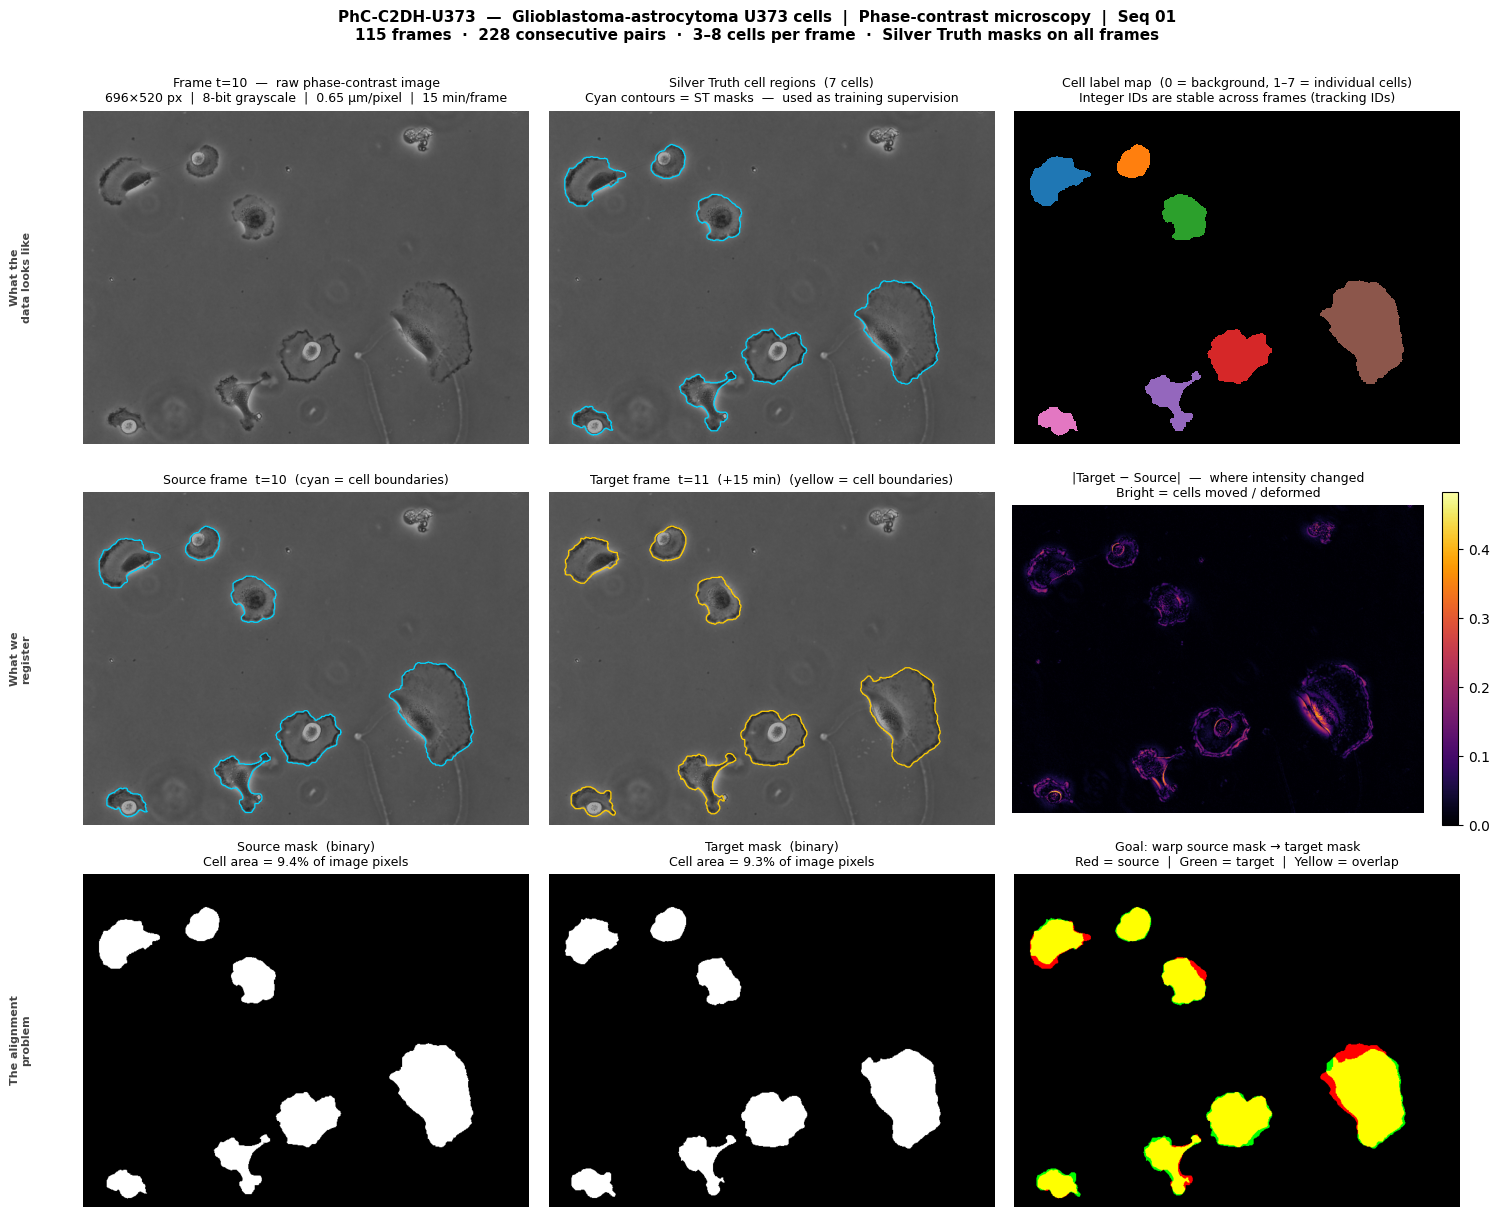

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from skimage import io
from pathlib import Path

#  Load two consecutive frames and their Silver Truth masks ─
frame_i, frame_j = 10, 11
seq_dir = Path('dataset/train/01')
st_dir  = Path('dataset/train/01_ST/SEG')

img_i  = io.imread(str(seq_dir / f't{frame_i:03d}.tif')).astype(np.float32) / 255.0
img_j  = io.imread(str(seq_dir / f't{frame_j:03d}.tif')).astype(np.float32) / 255.0
diff   = np.abs(img_j - img_i)

mask_i = io.imread(str(st_dir / f'man_seg{frame_i:03d}.tif')).astype(np.float32)
mask_j = io.imread(str(st_dir / f'man_seg{frame_j:03d}.tif')).astype(np.float32)

binary_i = mask_i > 0
binary_j = mask_j > 0
n_cells  = int(mask_i.max())

# Per-cell colour map: background = black, each cell = distinct colour
cell_cmap = ListedColormap(['black'] + [cm.tab10(i % 10) for i in range(n_cells)])

# Alignment overlay: red = source cells, green = target cells, yellow = overlap
align_rgb         = np.zeros((*img_i.shape, 3), dtype=np.float32)
align_rgb[..., 0] = binary_i.astype(float)
align_rgb[..., 1] = binary_j.astype(float)

#  Figure: 3 rows × 3 panels ─
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

kw_img = dict(cmap='gray', vmin=0, vmax=1)
kw_src = dict(colors=['#00d4ff'], linewidths=0.9, levels=[0.5])   # cyan  = source
kw_tgt = dict(colors=['#ffcc00'], linewidths=0.9, levels=[0.5])   # yellow = target

#  Row 0: single frame anatomy ─
axes[0, 0].imshow(img_i, **kw_img)
axes[0, 0].set_title(
    f'Frame t={frame_i}  —  raw phase-contrast image\n'
    f'696×520 px  |  8-bit grayscale  |  0.65 μm/pixel  |  15 min/frame', fontsize=9)

axes[0, 1].imshow(img_i, **kw_img)
axes[0, 1].contour(binary_i.astype(float), **kw_src)
axes[0, 1].set_title(
    f'Silver Truth cell regions  ({n_cells} cells)\n'
    f'Cyan contours = ST masks  —  used as training supervision', fontsize=9)

axes[0, 2].imshow(mask_i, cmap=cell_cmap, vmin=0, vmax=n_cells, interpolation='nearest')
axes[0, 2].set_title(
    f'Cell label map  (0 = background, 1–{n_cells} = individual cells)\n'
    f'Integer IDs are stable across frames (tracking IDs)', fontsize=9)

#  Row 1: consecutive pair
axes[1, 0].imshow(img_i, **kw_img)
axes[1, 0].contour(binary_i.astype(float), **kw_src)
axes[1, 0].set_title(f'Source frame  t={frame_i}  (cyan = cell boundaries)', fontsize=9)

axes[1, 1].imshow(img_j, **kw_img)
axes[1, 1].contour(binary_j.astype(float), **kw_tgt)
axes[1, 1].set_title(f'Target frame  t={frame_j}  (+15 min)  (yellow = cell boundaries)', fontsize=9)

im = axes[1, 2].imshow(diff, cmap='inferno', vmin=0, vmax=diff.max())
axes[1, 2].set_title('|Target − Source|  —  where intensity changed\nBright = cells moved / deformed', fontsize=9)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

#  Row 2: the registration problem ─
axes[2, 0].imshow(binary_i.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 0].set_title(
    f'Source mask  (binary)\n'
    f'Cell area = {binary_i.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 1].imshow(binary_j.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 1].set_title(
    f'Target mask  (binary)\n'
    f'Cell area = {binary_j.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 2].imshow(align_rgb)
axes[2, 2].set_title(
    'Goal: warp source mask → target mask\n'
    'Red = source  |  Green = target  |  Yellow = overlap', fontsize=9)

#  Row labels & final formatting ─
row_labels = ['What the\ndata looks like', 'What we\nregister', 'The alignment\nproblem']
for row, label in enumerate(row_labels):
    axes[row, 0].annotate(
        label, xy=(-0.14, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=8, fontweight='bold',
        rotation=90, color='#444444')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(
    'PhC-C2DH-U373  —  Glioblastoma-astrocytoma U373 cells  |  Phase-contrast microscopy  |  Seq 01\n'
    '115 frames  ·  228 consecutive pairs  ·  3–8 cells per frame  ·  Silver Truth masks on all frames',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Train — Masked MSE

Train **Masked MSE** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks (primary alignment signal)
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 0.01` — displacement field smoothness regularisation

In [5]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/masked_mse \
    --save-every 50

Device: cuda  |  Dataset: 114 pairs  |  Sequences: ['01']  |  Loss: MSE  |  Mode: mask-guided  |  lambda: 0.01

Epochs:   0% 0/200 [00:00<?, ?it/s]Epoch 1/200 — mask_dice_loss: 0.099198
Epochs:   4% 9/200 [00:45<15:37,  4.91s/it]Epoch 10/200 — mask_dice_loss: 0.098501
Epochs:  10% 19/200 [01:35<15:13,  5.05s/it]Epoch 20/200 — mask_dice_loss: 0.086437
Epochs:  14% 29/200 [02:27<14:32,  5.10s/it]Epoch 30/200 — mask_dice_loss: 0.073473
Epochs:  20% 39/200 [03:17<13:30,  5.04s/it]Epoch 40/200 — mask_dice_loss: 0.062420
Epochs:  24% 49/200 [04:08<12:30,  4.97s/it]Epoch 50/200 — mask_dice_loss: 0.057072
Epochs:  30% 59/200 [04:58<11:35,  4.94s/it]Epoch 60/200 — mask_dice_loss: 0.054518
Epochs:  34% 69/200 [05:48<10:48,  4.95s/it]Epoch 70/200 — mask_dice_loss: 0.050198
Epochs:  40% 79/200 [06:38<10:04,  5.00s/it]Epoch 80/200 — mask_dice_loss: 0.047732
Epochs:  44% 89/200 [07:29<09:37,  5.21s/it]Epoch 90/200 — mask_dice_loss: 0.046024
Epochs:  50% 99/200 [08:20<08:32,  5.08s/it]Epoch 100/200 —

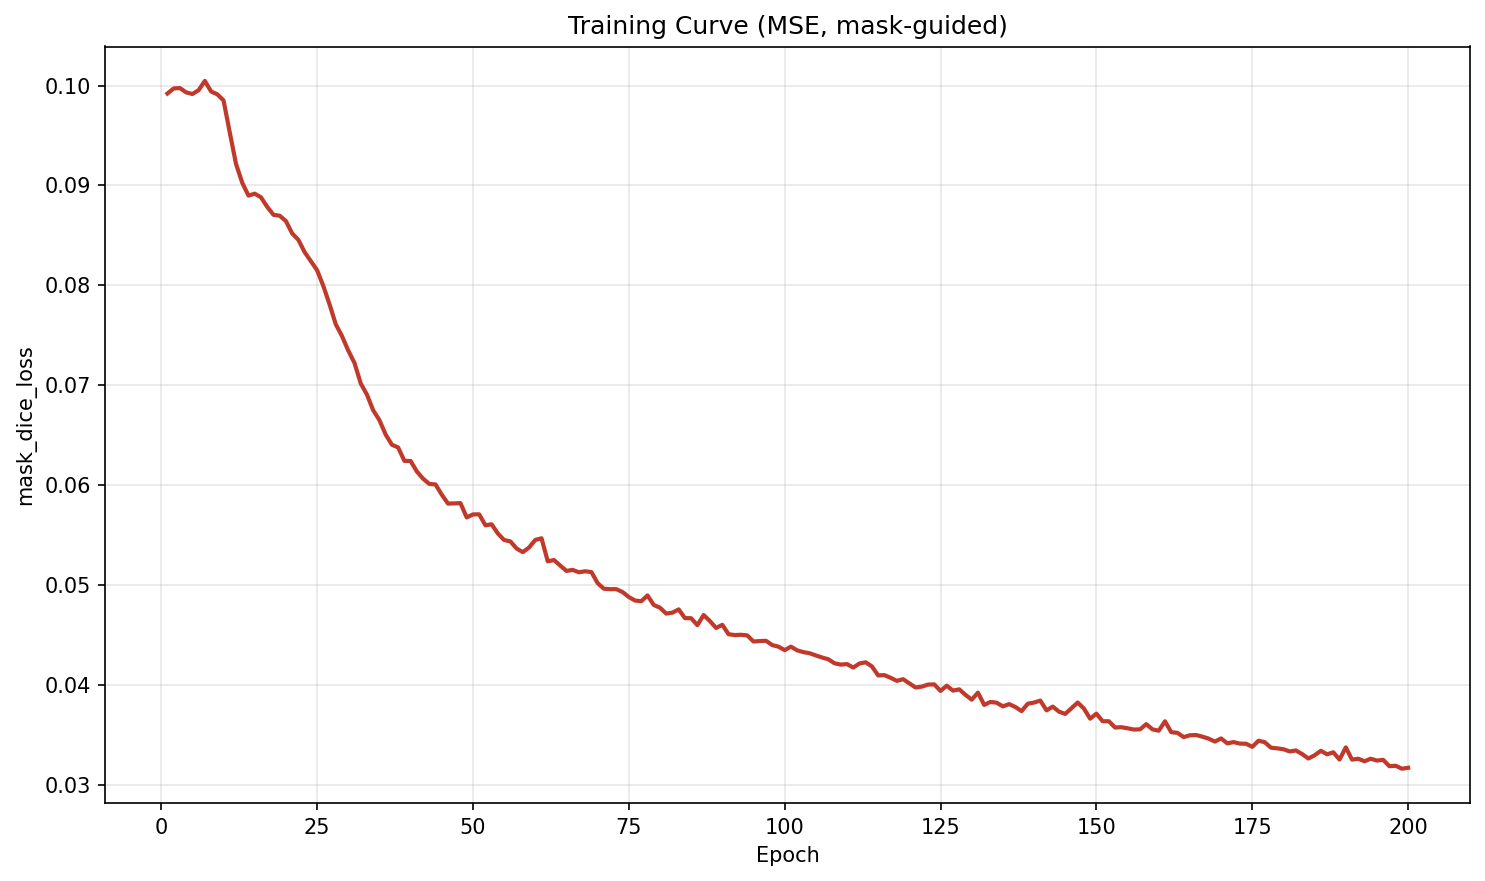

In [6]:
from IPython.display import Image, display
display(Image(filename='output/masked_mse/loss_curve.png', width=800))

## 5. Train — Normalized Cross-Correlation

Train **Normalized Cross-Correlation** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [7]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/ncc \
    --save-every 50

Device: cuda  |  Dataset: 114 pairs  |  Sequences: ['01']  |  Loss: NCC  |  Mode: mask-guided  |  lambda: 1.0

Epochs:   0% 0/200 [00:00<?, ?it/s]Epoch 1/200 — mask_dice_loss: 0.099425
Epochs:   4% 9/200 [00:49<17:13,  5.41s/it]Epoch 10/200 — mask_dice_loss: 0.093304
Epochs:  10% 19/200 [01:43<16:04,  5.33s/it]Epoch 20/200 — mask_dice_loss: 0.083123
Epochs:  14% 29/200 [02:37<15:26,  5.42s/it]Epoch 30/200 — mask_dice_loss: 0.075879
Epochs:  20% 39/200 [03:30<14:20,  5.34s/it]Epoch 40/200 — mask_dice_loss: 0.070746
Epochs:  24% 49/200 [04:24<13:29,  5.36s/it]Epoch 50/200 — mask_dice_loss: 0.066441
Epochs:  30% 59/200 [05:18<12:40,  5.39s/it]Epoch 60/200 — mask_dice_loss: 0.063389
Epochs:  34% 69/200 [06:11<11:39,  5.34s/it]Epoch 70/200 — mask_dice_loss: 0.060521
Epochs:  40% 79/200 [07:06<10:58,  5.45s/it]Epoch 80/200 — mask_dice_loss: 0.057751
Epochs:  44% 89/200 [07:59<09:55,  5.37s/it]Epoch 90/200 — mask_dice_loss: 0.055819
Epochs:  50% 99/200 [08:53<08:57,  5.32s/it]Epoch 100/200 — 

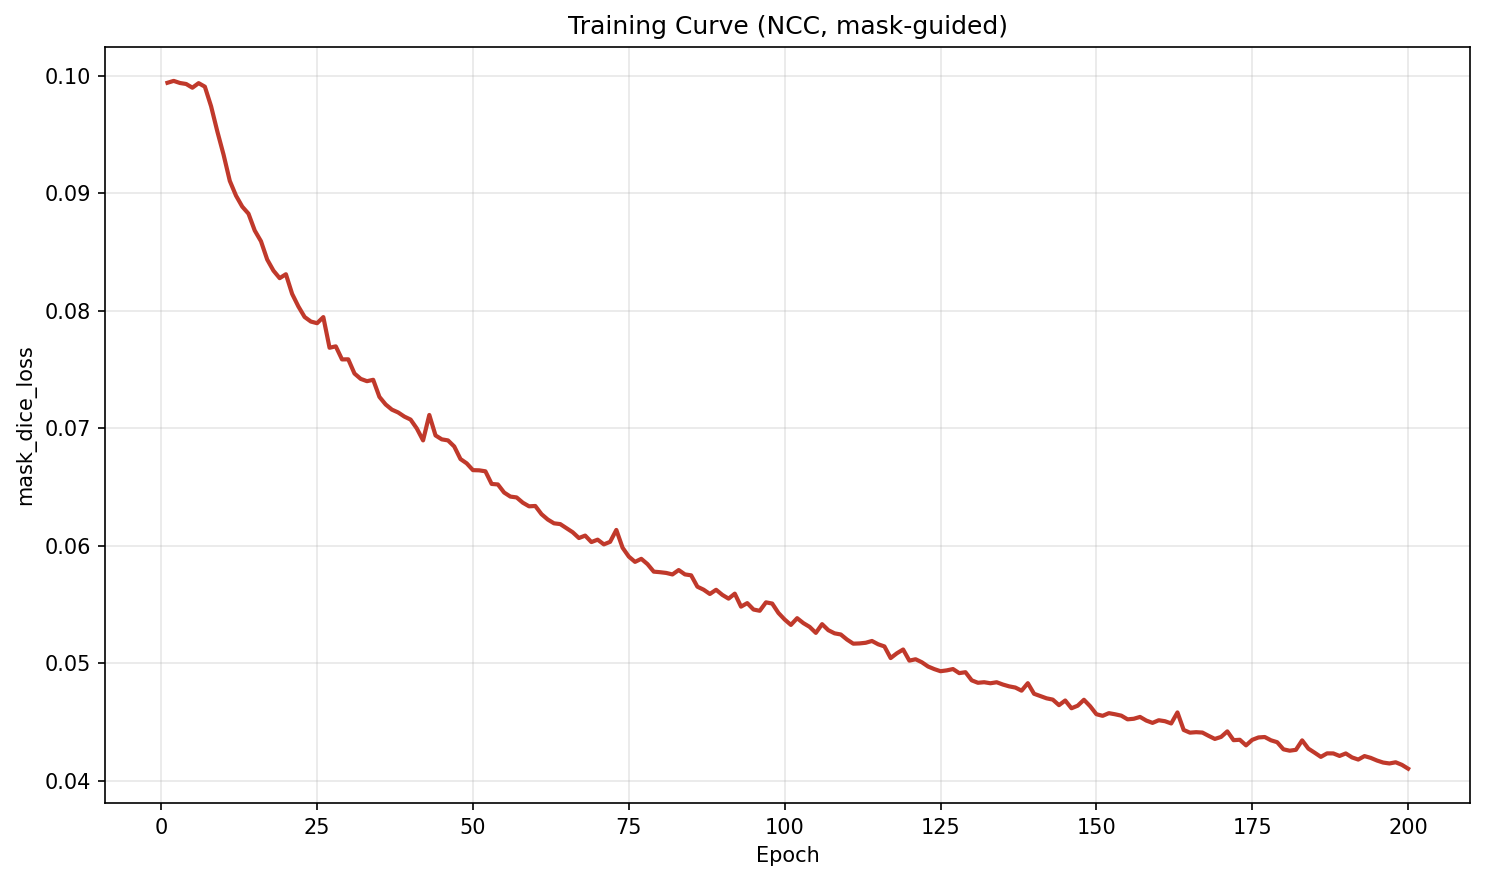

In [8]:
from IPython.display import Image, display
display(Image(filename='output/ncc/loss_curve.png', width=800))

## 6. Train — SSIM

Train **SSIM** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [9]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss ssim --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/ssim \
    --save-every 50

Device: cuda  |  Dataset: 114 pairs  |  Sequences: ['01']  |  Loss: SSIM  |  Mode: mask-guided  |  lambda: 1.0

Epochs:   0% 0/200 [00:00<?, ?it/s]Epoch 1/200 — mask_dice_loss: 0.099591
Epochs:   4% 9/200 [00:48<16:59,  5.34s/it]Epoch 10/200 — mask_dice_loss: 0.096795
Epochs:  10% 19/200 [01:40<15:51,  5.26s/it]Epoch 20/200 — mask_dice_loss: 0.084548
Epochs:  14% 29/200 [02:33<14:52,  5.22s/it]Epoch 30/200 — mask_dice_loss: 0.077483
Epochs:  20% 39/200 [03:26<14:14,  5.31s/it]Epoch 40/200 — mask_dice_loss: 0.071775
Epochs:  24% 49/200 [04:18<13:18,  5.29s/it]Epoch 50/200 — mask_dice_loss: 0.067508
Epochs:  30% 59/200 [05:11<12:25,  5.29s/it]Epoch 60/200 — mask_dice_loss: 0.062467
Epochs:  34% 69/200 [06:04<11:31,  5.28s/it]Epoch 70/200 — mask_dice_loss: 0.056927
Epochs:  40% 79/200 [06:57<10:38,  5.27s/it]Epoch 80/200 — mask_dice_loss: 0.052348
Epochs:  44% 89/200 [07:49<09:43,  5.26s/it]Epoch 90/200 — mask_dice_loss: 0.049198
Epochs:  50% 99/200 [08:41<08:47,  5.22s/it]Epoch 100/200 —

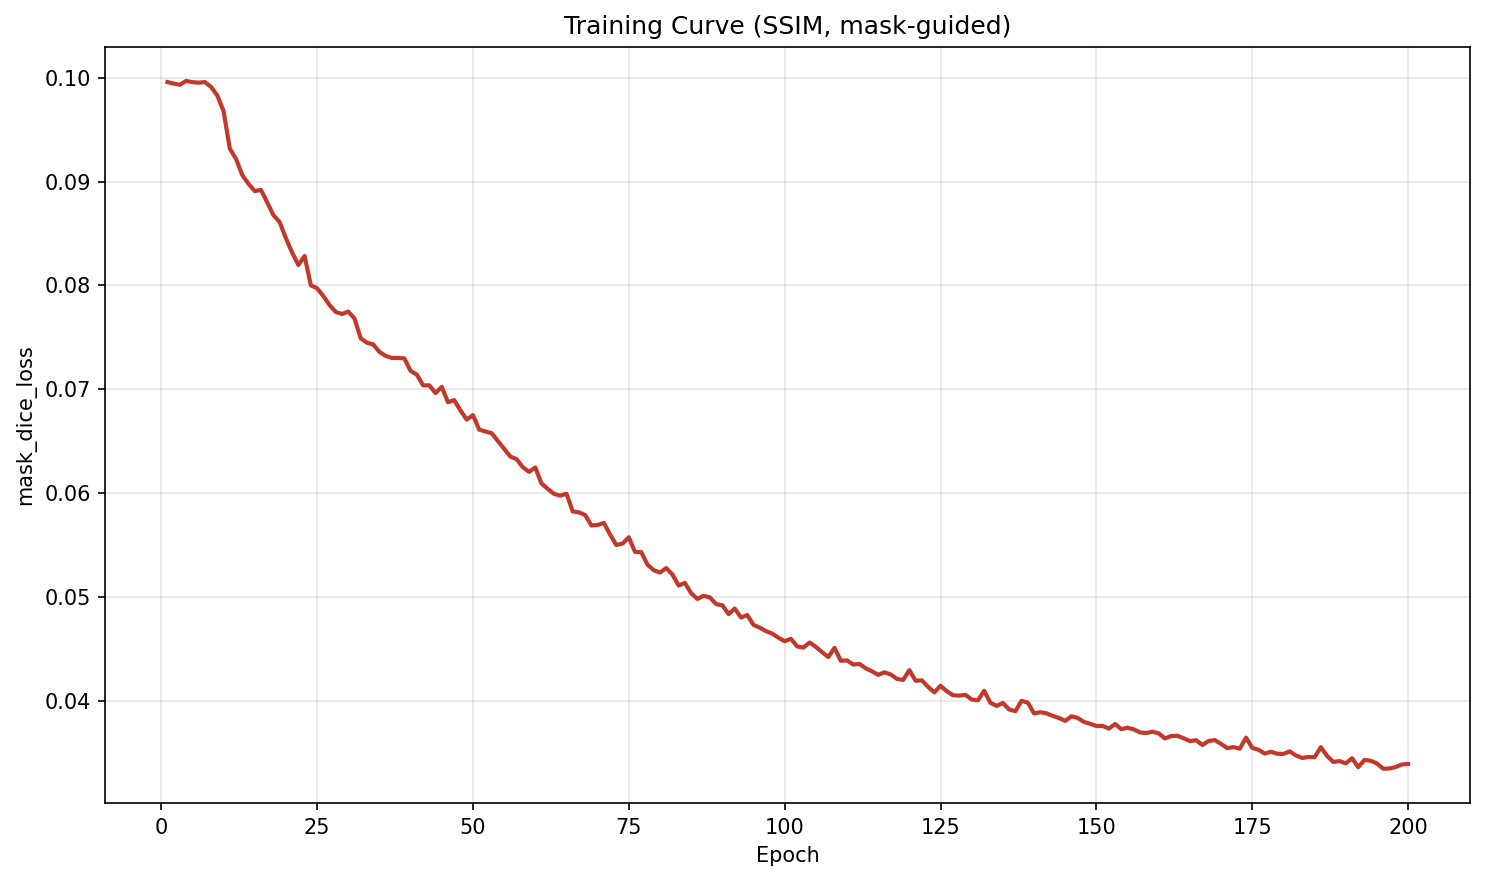

In [10]:
from IPython.display import Image, display
display(Image(filename='output/ssim/loss_curve.png', width=800))

## 7. Evaluate — Masked MSE

Evaluate on held-out sequence 02. Includes Horn & Schunck, Farneback, and TV-L1 baselines.

In [11]:
!python -m scripts.cell_tracking.evaluate \
    --model output/masked_mse/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_masked_mse \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: True

Evaluating 114 pairs...

  Pair 0: Dice=0.8562, MaskedMSE=0.007171
  Pair 1: Dice=0.8183, MaskedMSE=0.008879
  Pair 2: Dice=0.8396, MaskedMSE=0.009854
  Pair 3: Dice=0.7264, MaskedMSE=0.008281
  Pair 4: Dice=0.8271, MaskedMSE=0.006636
  Pair 5: Dice=0.8788, MaskedMSE=0.006747
  Pair 6: Dice=0.8466, MaskedMSE=0.006313
  Pair 7: Dice=0.8566, MaskedMSE=0.005652
  Pair 8: Dice=0.8449, MaskedMSE=0.006219
  Pair 9: Dice=0.8407, MaskedMSE=0.006738
  Pair 10: Dice=0.8166, MaskedMSE=0.006335
  Pair 11: Dice=0.8292, MaskedMSE=0.006893
  Pair 12: Dice=0.8465, MaskedMSE=0.006495
  Pair 13: Dice=0.7358, MaskedMSE=0.006453
  Pair 14: Dice=0.8271, MaskedMSE=0.007765
  Pair 15: Dice=0.8600, MaskedMSE=0.005634
  Pair 16: Dice=0.8780, MaskedMSE=0.005480
  Pair 17: Dice=0.8465, MaskedMSE=0.005559
  Pair 18: Dice=0.8799, MaskedMSE=0.005704
  Pair 19: Dice=0.8778, MaskedMSE=0.006103
  Pair 20: Dice=0.8629, MaskedMSE=0.006440
  Pair 21: Dice=0.6648

## 8. Evaluate — Normalized Cross-Correlation

Evaluate on held-out sequence 02. Baseline numbers reused from section 7.

In [12]:
!python -m scripts.cell_tracking.evaluate \
    --model output/ncc/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_ncc \
    --no-baselines \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: False

Evaluating 114 pairs...

  Pair 0: Dice=0.9227, MaskedMSE=0.002662
  Pair 1: Dice=0.8840, MaskedMSE=0.005400
  Pair 2: Dice=0.9004, MaskedMSE=0.005393
  Pair 3: Dice=0.7692, MaskedMSE=0.005913
  Pair 4: Dice=0.9067, MaskedMSE=0.003964
  Pair 5: Dice=0.9191, MaskedMSE=0.004001
  Pair 6: Dice=0.9291, MaskedMSE=0.003663
  Pair 7: Dice=0.9333, MaskedMSE=0.002686
  Pair 8: Dice=0.9100, MaskedMSE=0.003496
  Pair 9: Dice=0.9154, MaskedMSE=0.003966
  Pair 10: Dice=0.9343, MaskedMSE=0.003199
  Pair 11: Dice=0.9241, MaskedMSE=0.003744
  Pair 12: Dice=0.9186, MaskedMSE=0.004058
  Pair 13: Dice=0.7739, MaskedMSE=0.003880
  Pair 14: Dice=0.9053, MaskedMSE=0.005082
  Pair 15: Dice=0.9111, MaskedMSE=0.003914
  Pair 16: Dice=0.9205, MaskedMSE=0.003355
  Pair 17: Dice=0.9169, MaskedMSE=0.003129
  Pair 18: Dice=0.9312, MaskedMSE=0.002881
  Pair 19: Dice=0.9348, MaskedMSE=0.003110
  Pair 20: Dice=0.9086, MaskedMSE=0.003700
  Pair 21: Dice=0.727

pair_0000.png


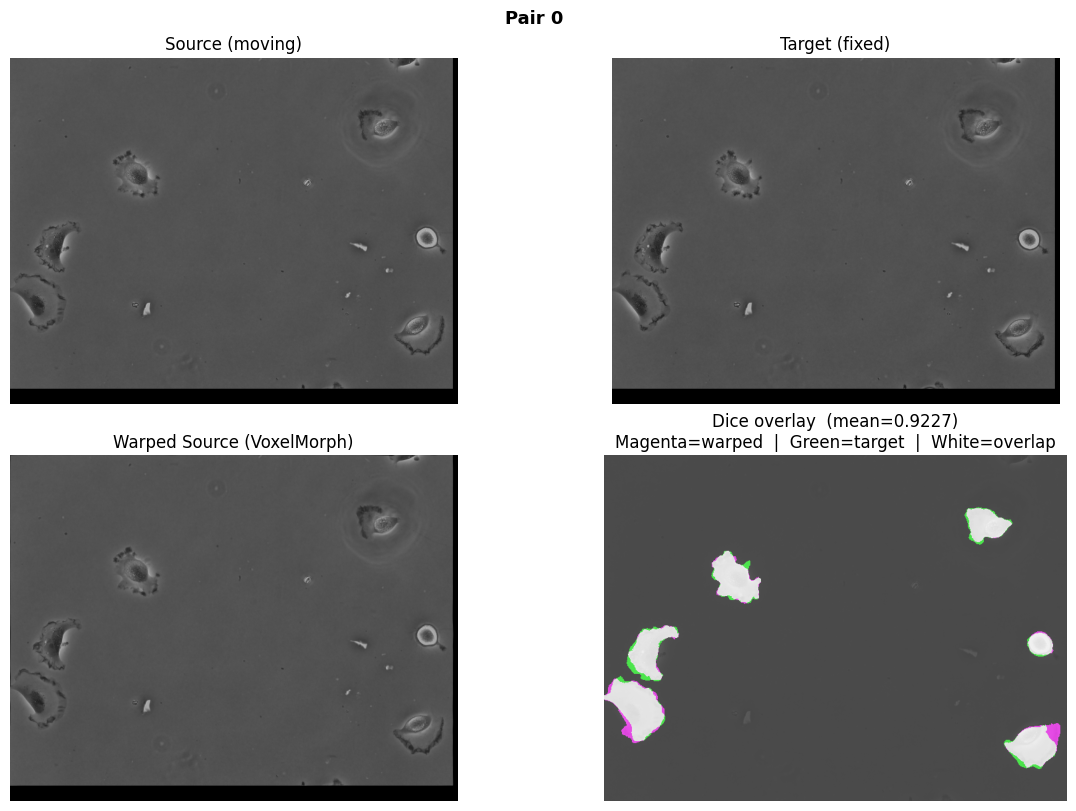

pair_0001.png


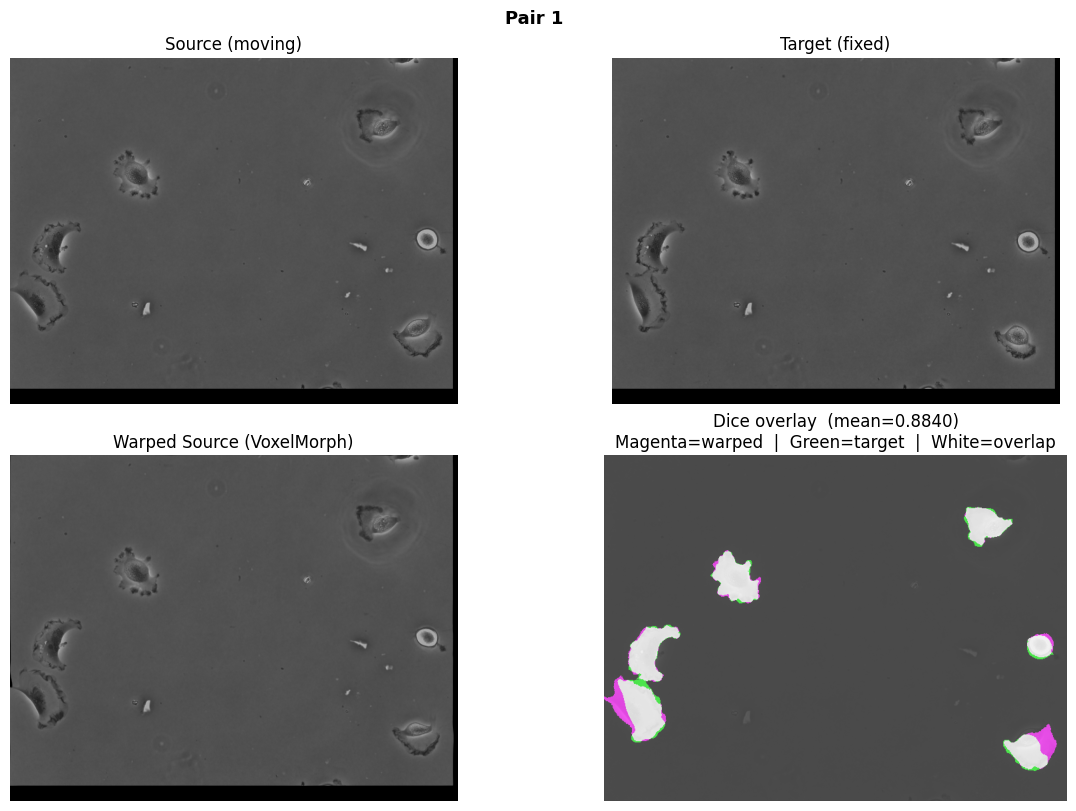

pair_0002.png


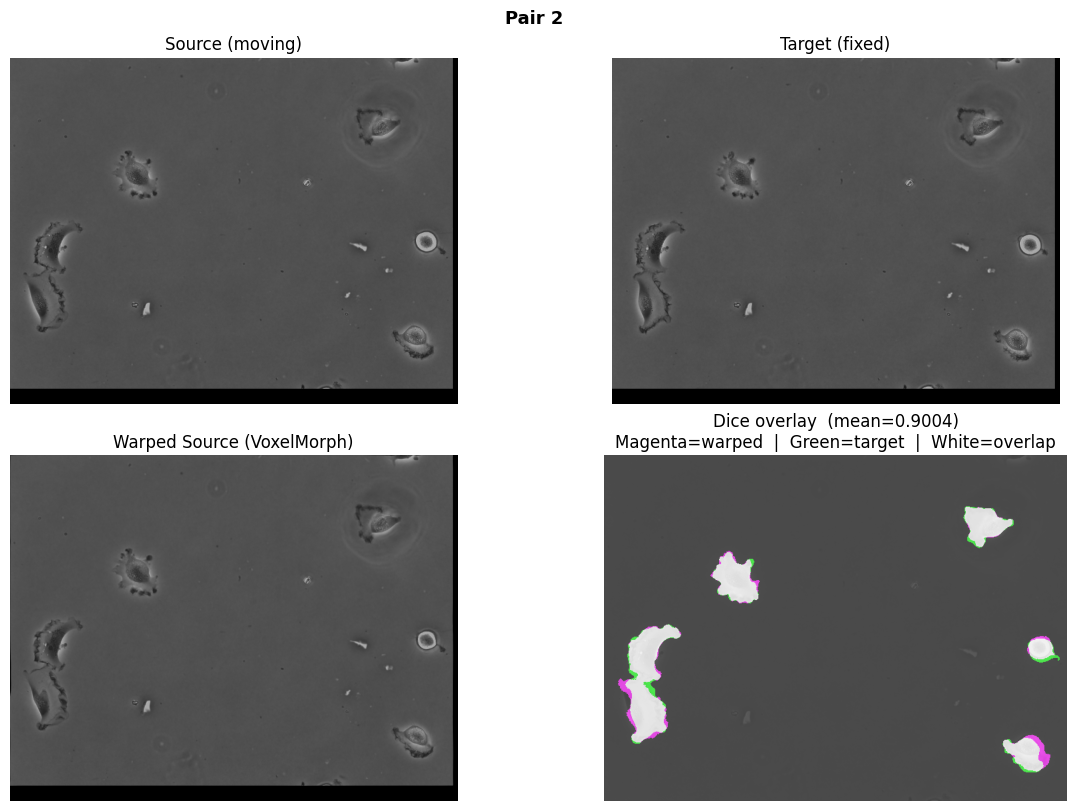

In [13]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_ncc').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

## 9. Evaluate — SSIM

Evaluate on held-out sequence 02. Baseline numbers reused from section 7.

In [14]:
!python -m scripts.cell_tracking.evaluate \
    --model output/ssim/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_ssim \
    --no-baselines \
    --max-pairs 0

Device: cuda
Sequences: ['02']
Pairs: 114, Baselines: False

Evaluating 114 pairs...

  Pair 0: Dice=0.9145, MaskedMSE=0.002396
  Pair 1: Dice=0.8599, MaskedMSE=0.004872
  Pair 2: Dice=0.8763, MaskedMSE=0.004349
  Pair 3: Dice=0.7638, MaskedMSE=0.005039
  Pair 4: Dice=0.8891, MaskedMSE=0.003159
  Pair 5: Dice=0.9019, MaskedMSE=0.003870
  Pair 6: Dice=0.9190, MaskedMSE=0.002632
  Pair 7: Dice=0.9172, MaskedMSE=0.002334
  Pair 8: Dice=0.8952, MaskedMSE=0.002761
  Pair 9: Dice=0.9011, MaskedMSE=0.003321
  Pair 10: Dice=0.9057, MaskedMSE=0.002358
  Pair 11: Dice=0.9050, MaskedMSE=0.003219
  Pair 12: Dice=0.9063, MaskedMSE=0.003249
  Pair 13: Dice=0.7675, MaskedMSE=0.003668
  Pair 14: Dice=0.8909, MaskedMSE=0.004193
  Pair 15: Dice=0.8954, MaskedMSE=0.003008
  Pair 16: Dice=0.9166, MaskedMSE=0.003102
  Pair 17: Dice=0.9051, MaskedMSE=0.002613
  Pair 18: Dice=0.9268, MaskedMSE=0.002490
  Pair 19: Dice=0.9302, MaskedMSE=0.002605
  Pair 20: Dice=0.8962, MaskedMSE=0.002938
  Pair 21: Dice=0.709

pair_0000.png


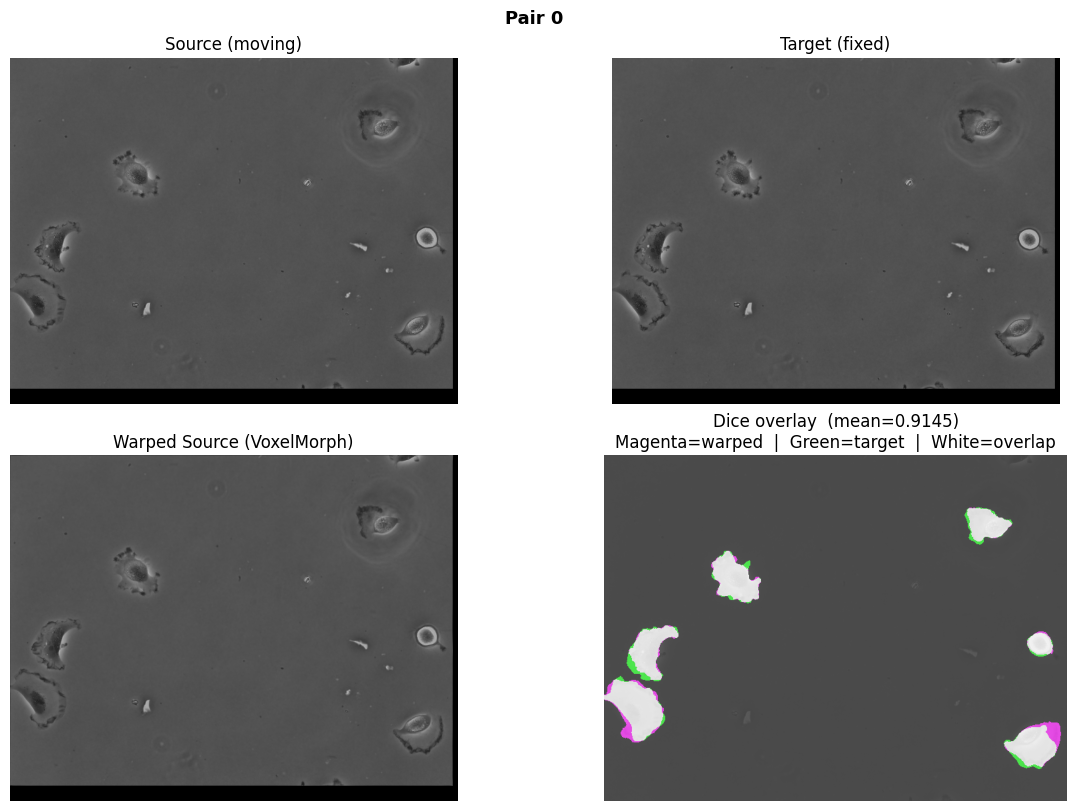

pair_0001.png


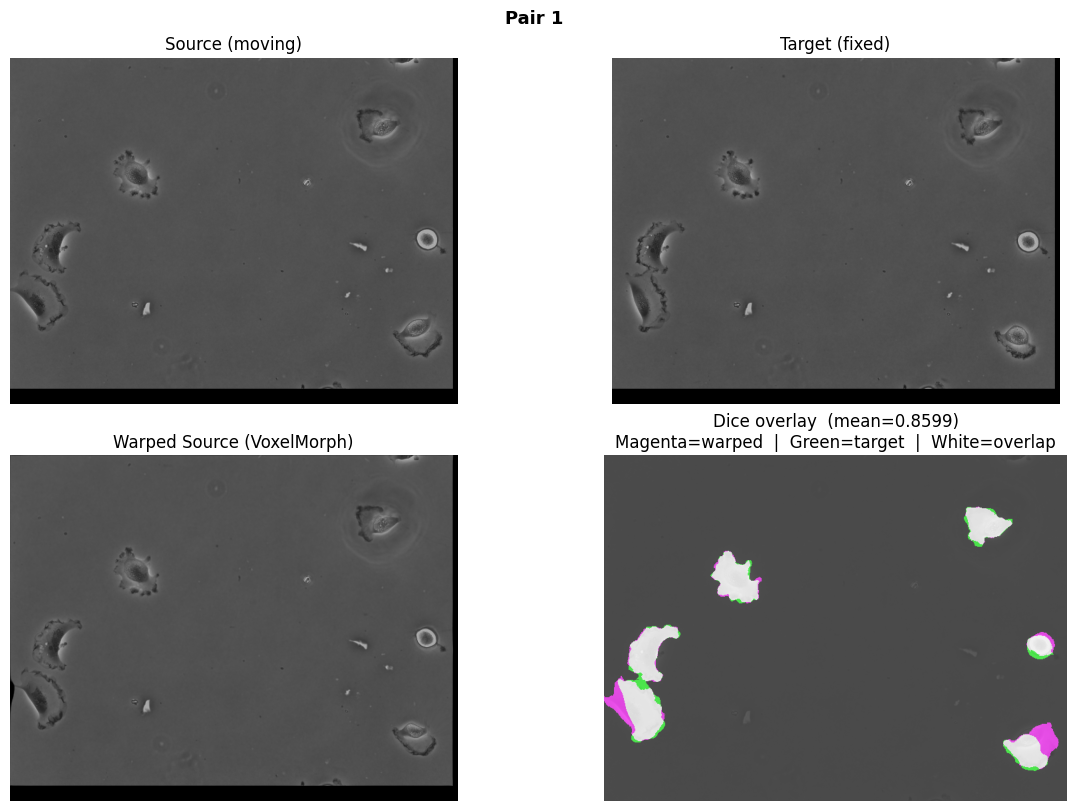

pair_0002.png


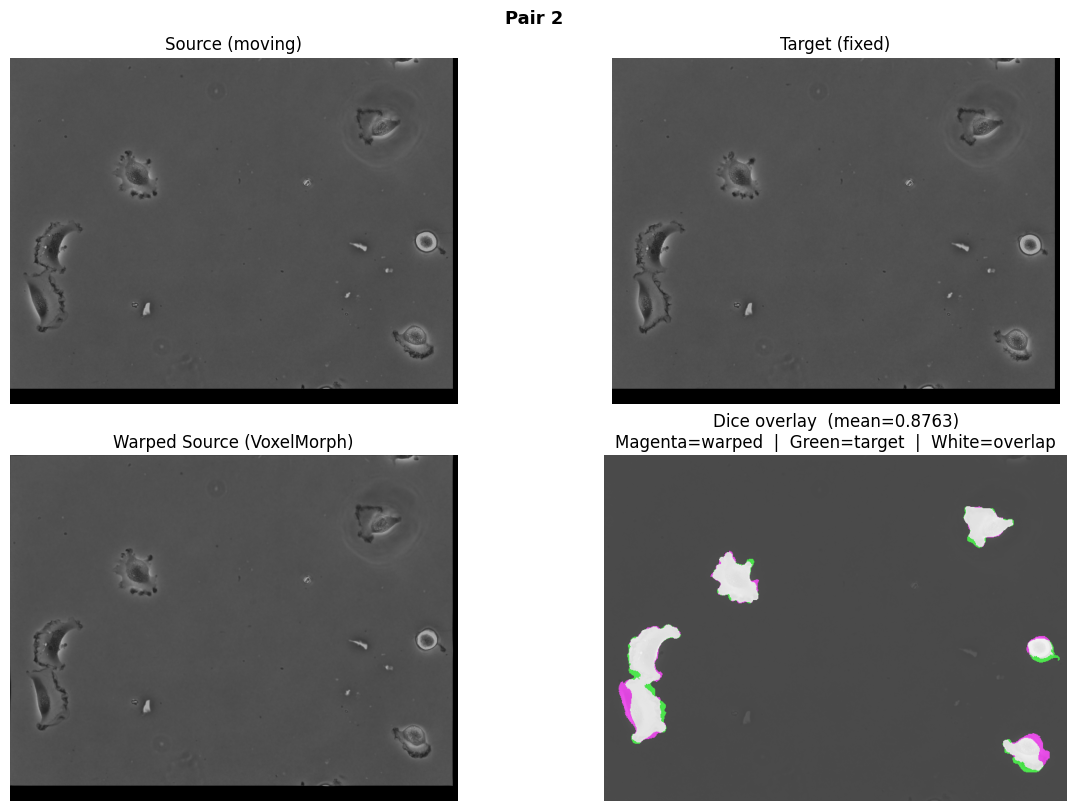

In [15]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_ssim').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

## 10. Results

Comparison across methods evaluated on sequence 02 (held-out from training).

In [16]:
import json
import pandas as pd
from pathlib import Path


def load_metrics(path: str, key: str) -> dict | None:
    p = Path(path)
    if not p.exists():
        return None
    return json.loads(p.read_text()).get(key)


def fmt(metrics: dict) -> dict:
    dice = (
        f"{metrics['dice_mean']:.4f} ± {metrics['dice_std']:.4f}"
        if 'dice_mean' in metrics else '—'
    )
    mse = (
        f"{metrics['masked_mse_mean']:.6f} ± {metrics['masked_mse_std']:.6f}"
        if 'masked_mse_mean' in metrics else '—'
    )
    runtime = (
        f"{metrics['runtime_mean']:.4f}"
        if 'runtime_mean' in metrics else '—'
    )
    return {'Dice': dice, 'MSE': mse, 'Runtime (s)': runtime}


rows = []

baseline_json = 'output/eval_masked_mse/metrics.json'
for key, label in [
    ('horn_schunck', 'Horn & Schunck'),
    ('farneback',    'Farneback'),
    ('tvl1',         'TV-L1'),
]:
    m = load_metrics(baseline_json, key)
    if m:
        rows.append({'Method': label, **fmt(m)})

for name, eval_dir in [
    ('Masked MSE',                   'output/eval_masked_mse'),
    ('Normalized Cross-Correlation', 'output/eval_ncc'),
    ('SSIM',                         'output/eval_ssim'),
]:
    m = load_metrics(f'{eval_dir}/metrics.json', 'vxm')
    if m:
        rows.append({'Method': name, **fmt(m)})

pd.DataFrame(rows).set_index('Method')

,Dice,MSE,Runtime (s)
Method,,,
Horn & Schunck,0.8806 ± 0.0629,0.004457 ± 0.001300,5.9105
Farneback,0.8162 ± 0.0657,0.008819 ± 0.002019,0.1147
TV-L1,0.8306 ± 0.0633,0.008955 ± 0.002028,6.6605
Masked MSE,0.8196 ± 0.0593,0.008168 ± 0.001476,0.0117
Normalized Cross-Correlation,0.8815 ± 0.0631,0.004095 ± 0.001125,0.0114
SSIM,0.8684 ± 0.0637,0.003445 ± 0.000973,0.0114
